In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split
import time
import json
from sklearn.preprocessing import StandardScaler


In [14]:
df  = pd.DataFrame({'set' : ['baseline_acc', 'baseline_sg', 'baseline_comb','attn_acc', 'attn_sg', 'attn_comb'],
'SET1 (Jul 2022)' : [0.111 , 0.111 , 0.111 , 0.111 ,0.111 , 0.111 ],
'SET2 (Apr 2023)': [0.211, 0.227 , 0.219 ,1.994 , 0.785 , 2.175 ],
'SET3 (Aug 2023)': [0.112 , 0.148, 0.130 , 1.301 , 0.839 , 1.504] ,
'SET4 (Jan 2024)': [0.073,0.732 ,0.403 , 2.342 , 0.937 , 2.459] ,
'SET5 (Jun 2024)': [0.142, 0.157 ,0.149 ,1.685, 0.901, 1.959 ]})


df = df.set_index('set').T

In [15]:
df

set,baseline_acc,baseline_sg,baseline_comb,attn_acc,attn_sg,attn_comb
SET1 (Jul 2022),0.111,0.111,0.111,0.111,0.111,0.111
SET2 (Apr 2023),0.211,0.227,0.219,1.994,0.785,2.175
SET3 (Aug 2023),0.112,0.148,0.130,1.301,0.839,1.504
SET4 (Jan 2024),0.073,0.732,0.403,2.342,0.937,2.459
SET5 (Jun 2024),0.142,0.157,0.149,1.685,0.901,1.959


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert from wide to long
long = (
    df.reset_index(names = 'set')
    .melt(id_vars="set", var_name="metric", value_name="value")
)

# Split "baseline_acc" -> method="baseline", type="acc"
long[["method", "type"]] = long["metric"].str.split("_", n=1, expand=True)


long["type"] = long["type"].replace({
    "acc": "Accelerometers",
    "sg": "Strain Gauges",
    "comb": "All sensors"
})

print(long.head())

               set        metric  value    method            type
0  SET1 (Jul 2022)  baseline_acc  0.111  baseline  Accelerometers
1  SET2 (Apr 2023)  baseline_acc  0.211  baseline  Accelerometers
2  SET3 (Aug 2023)  baseline_acc  0.112  baseline  Accelerometers
3  SET4 (Jan 2024)  baseline_acc  0.073  baseline  Accelerometers
4  SET5 (Jun 2024)  baseline_acc  0.142  baseline  Accelerometers


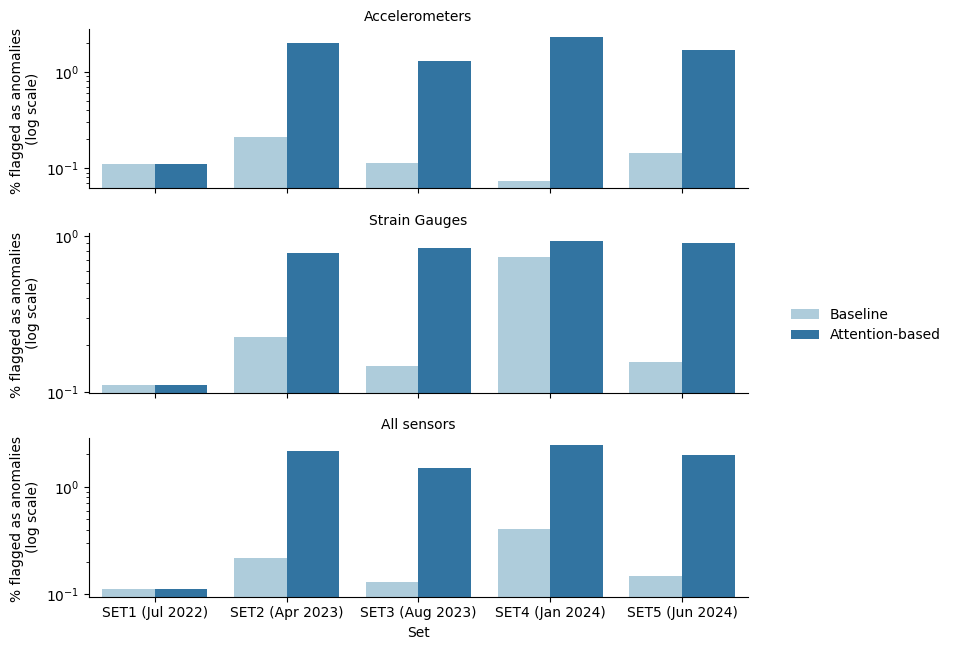

In [76]:
g = sns.catplot(
    data=long,
    kind="bar",
    x="set",
    y="value",
    hue="method",      # baseline vs attn
    row="type",        # acc, sg, comb
    sharey=False,      # optional
    height=2.2,
    aspect=3,
    palette = 'Paired'
)

sns.move_legend(
    g,
    "center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Method",
    frameon=False
)



for ax in g.axes.flat:
    ax.set_yscale("log")


g.set_ylabels("% flagged as anomalies \n(log scale)")
g.set_xlabels('Set')
g.set_titles("{row_name}")


g.legend.set_title("")
new_labels = ["Baseline", "Attention-based"]

for text, label in zip(g.legend.texts, new_labels):
    text.set_text(label)


#g.set_xticklabels(rotation=30)
g.fig.tight_layout()
g.fig.savefig("barchart.png", dpi=300, bbox_inches="tight")
plt.show()

In [2]:
path = Path('..//..//results//15062026//nn_inputs')

acc = np.load(Path(path, 'acc_inputs.npy'))

strain = np.load(Path(path, 'strain_inputs.npy'))

temp = np.load(Path(path, 'temperature_inputs.npy'))

event_ids = np.load(Path(path, 'event_ids.npy'))

In [3]:
with open(f'{path}//metadata//sensor_ids.json') as f:
    sensor_names = json.load(f)

In [4]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [77]:
#### Wanting to look at the latent scores

In [223]:
path = Path('C://Users//lbreivik//Downloads//latent_scores')

In [259]:
import os
from sklearn.decomposition import PCA
from matplotlib.colors import TwoSlopeNorm

os.listdir(path)

['latent_scores_all_sets.csv',
 'latent_scores_SET1.csv',
 'latent_scores_SET1_test.csv',
 'latent_scores_SET1_train.csv',
 'latent_scores_SET1_train_full.csv',
 'latent_scores_SET2.csv',
 'latent_scores_SET3.csv',
 'latent_scores_SET4.csv',
 'latent_scores_SET5.csv',
 'latent_scores_test.csv']

In [260]:
set1_full = pd.read_csv(Path(path, 'latent_scores_SET1_train_full.csv'))
set1_full

,event_id,set,temperature_C,anomaly_score,error_strain,error_acc,above_threshold,latent_000,latent_001,latent_002,...,latent_246,latent_247,latent_248,latent_249,latent_250,latent_251,latent_252,latent_253,latent_254,latent_255
0,AQUINAS_SET1_2022_07__NEW__2022-07-01T02-39-01...,SET1,12.4773,0.399837,0.051286,0.348500,0,0.022390,0.110142,0.241675,...,-0.039108,0.228488,0.324715,0.530962,0.122894,0.221874,0.157981,0.093130,0.600484,0.038657
1,AQUINAS_SET1_2022_07__NEW__2022-07-01T03-12-51...,SET1,12.2423,0.216202,0.060632,0.155527,0,0.035154,0.277432,0.247554,...,-0.066113,0.302886,0.282486,0.471565,0.084246,0.204561,0.208489,0.045280,0.482927,-0.043264
2,AQUINAS_SET1_2022_07__NEW__2022-07-01T03-19-57...,SET1,12.2423,0.257207,0.050927,0.206207,0,0.174786,0.142967,0.171632,...,-0.121342,0.369158,0.370802,0.499413,0.105396,0.161333,0.230923,0.152269,0.496582,0.018352
3,AQUINAS_SET1_2022_07__NEW__2022-07-01T03-32-00...,SET1,11.7173,0.328872,0.060226,0.268548,0,0.056238,0.251075,0.259056,...,-0.092612,0.267070,0.365762,0.560683,0.090407,0.184276,0.215439,0.122989,0.505556,-0.051801
4,AQUINAS_SET1_2022_07__NEW__2022-07-01T03-38-18...,SET1,11.9913,0.248208,0.066382,0.181723,0,-0.005856,0.277074,0.250184,...,-0.102372,0.442560,0.368797,0.360111,0.054552,0.115912,0.202183,0.109816,0.440417,-0.047942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3583,AQUINAS_SET1_2022_07__NEW__2022-07-31T22-27-48...,SET1,19.5705,0.245953,0.064763,0.181136,0,0.164621,0.222827,0.270266,...,-0.078604,0.246989,0.213440,0.527603,0.084642,0.128420,0.258094,0.131956,0.573299,-0.003836
3584,AQUINAS_SET1_2022_07__NEW__2022-07-31T22-48-01...,SET1,19.7120,0.207379,0.062357,0.144984,0,0.129057,0.328999,0.220287,...,-0.044335,0.269610,0.363919,0.463825,0.126482,0.270377,0.382982,0.145451,0.447747,0.054148
3585,AQUINAS_SET1_2022_07__NEW__2022-07-31T23-43-31...,SET1,19.8219,0.228412,0.066147,0.162247,0,0.110746,0.171169,0.126459,...,-0.095126,0.222430,0.403276,0.490356,0.032106,0.212913,0.223915,0.120102,0.513239,-0.036591
3586,AQUINAS_SET1_2022_07__NEW__2022-07-31T23-54-56...,SET1,19.7590,0.227403,0.054208,0.173171,0,0.097919,0.330116,0.165833,...,-0.063254,0.354375,0.405803,0.338451,0.023428,0.227735,0.295896,0.175034,0.508422,-0.047817


In [261]:
train = pd.read_csv(Path(path, 'latent_scores_SET1_train.csv'))

train = pd.merge(train, set1_full)


In [262]:
test = pd.read_csv(Path(path, 'latent_scores_SET1_test.csv'))

test = pd.merge(test, set1_full)


In [263]:
latent_cols = train.columns[train.columns.str.startswith('latent')]

train_arr = train[latent_cols].to_numpy()
test_arr = test[latent_cols].to_numpy()


ss = StandardScaler()

#train_arr = ss.fit_transform(train_arr)

In [264]:
pca = PCA(n_components=2)

In [265]:
train_2comp = pca.fit_transform(train_arr)
test_2comp = pca.fit_transform(test_arr)


In [266]:
train_2comp

array([[-0.46942611, -0.13613253],
       [-0.28977875,  0.61117072],
       [-0.49343026, -0.12246024],
       ...,
       [-0.44253481,  0.29451087],
       [-0.41440727,  0.16256615],
       [-0.42335264,  0.66776743]])

<Axes: >

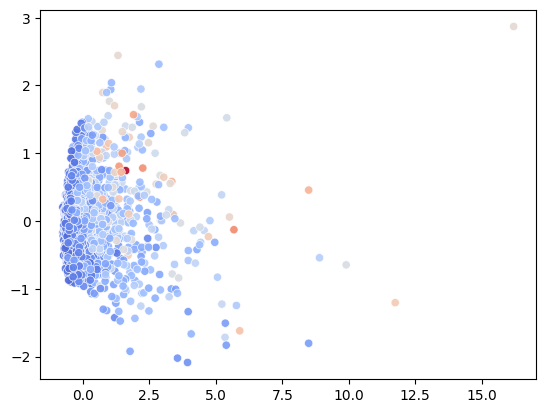

In [267]:
sns.scatterplot(x = train_2comp[:,0],y = train_2comp[:,1], hue = train['anomaly_score'], legend = False, palette = 'coolwarm', alpha = 0.9)


<Axes: >

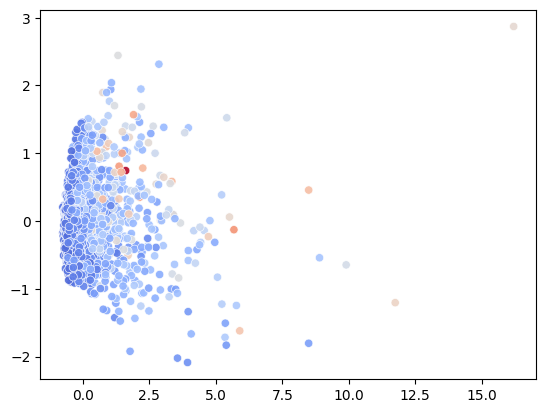

In [268]:
sns.scatterplot(x = train_2comp[:,0],y = train_2comp[:,1], hue = train['error_acc'], legend = False, palette = 'coolwarm', alpha = 0.9)


<Axes: >

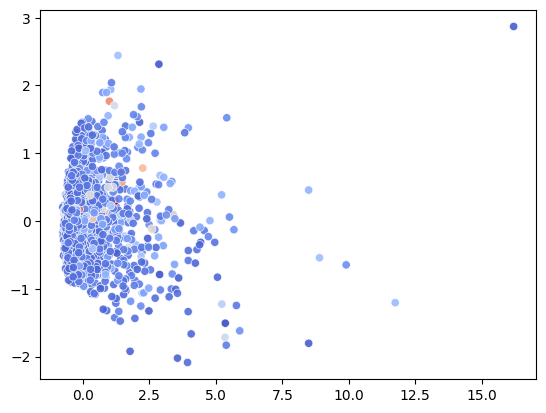

In [269]:
sns.scatterplot(x = train_2comp[:,0],y = train_2comp[:,1], hue = train['error_strain'], legend = False, palette = 'coolwarm', alpha = 0.9)


<Axes: >

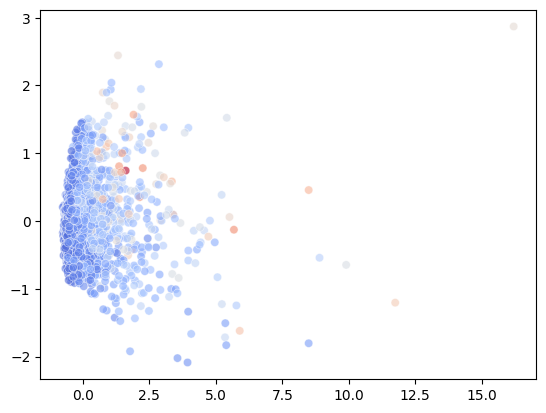

In [270]:
sns.scatterplot(x = train_2comp[:,0],y = train_2comp[:,1], hue = train['anomaly_score'], legend = False, palette = 'coolwarm', alpha = 0.6)

<Axes: >

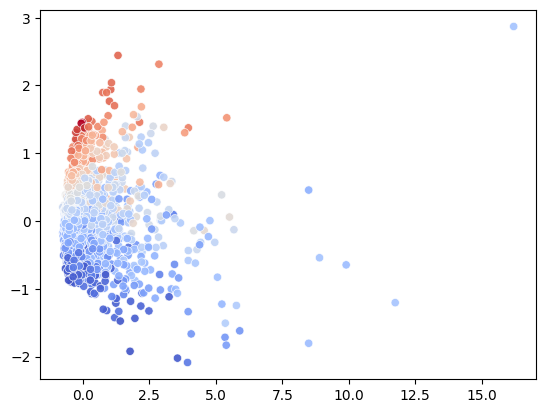

In [271]:
sns.scatterplot(x = train_2comp[:,0],y = train_2comp[:,1], hue = train['temperature_C'], legend = False, palette = 'coolwarm', alpha = 0.9)


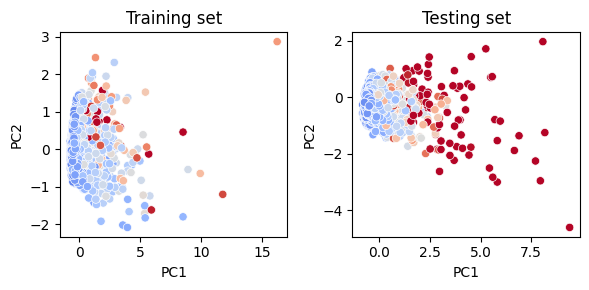

In [283]:
norm = TwoSlopeNorm(vmin=0, vcenter=0.666, vmax=1)


plt.figure(figsize=(6,3))

plt.subplot(121)
sns.scatterplot(x = train_2comp[:,0],
                y = train_2comp[:,1], 
                hue = train['anomaly_score'], 
                legend = False, palette = 'coolwarm', 
                alpha = 1,
                hue_norm = norm)

plt.title('Training set')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(122)
sns.scatterplot(x = test_2comp[:,0],
                y = test_2comp[:,1], 
                hue = test['anomaly_score'], 
                legend = False, palette = 'coolwarm', 
                alpha = 1,
                hue_norm = norm)
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('Testing set')

plt.tight_layout()


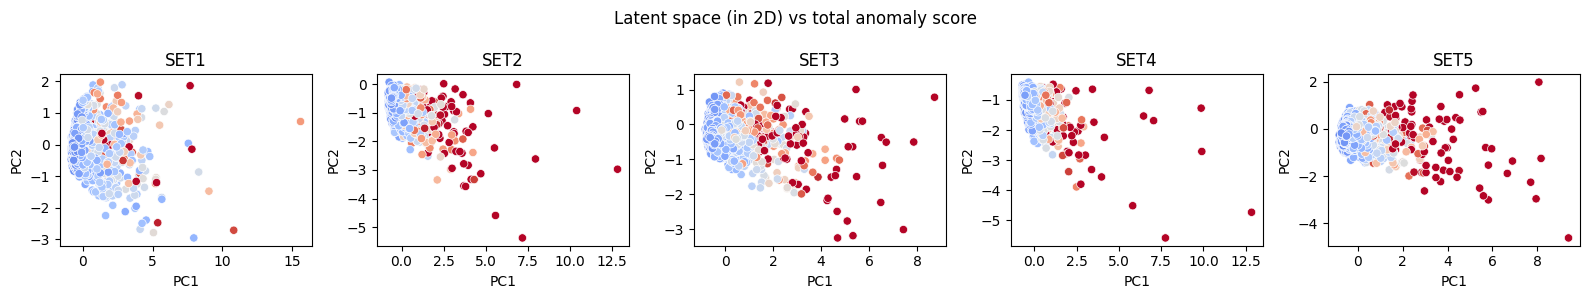

In [284]:
norm = TwoSlopeNorm(vmin=0, vcenter=0.666, vmax=1)


plt.figure(figsize = (16,3))

for i in range(1,6):
    test = pd.read_csv(Path(path, f'latent_scores_SET{i}.csv'))

    test_arr = test[latent_cols].to_numpy()

    plt.subplot(1,5,i)

    #test_arr = ss.transform(test_arr)
    plt.title(f'SET{i}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    test_2comp = pca.transform(test_arr)
    sns.scatterplot(x = test_2comp[:,0],y = test_2comp[:,1], 
                    hue = test['anomaly_score'], legend = False, 
                    palette = 'coolwarm', alpha = 1,
                    hue_norm = norm)

plt.suptitle('Latent space (in 2D) vs total anomaly score')
plt.tight_layout()
plt.show()

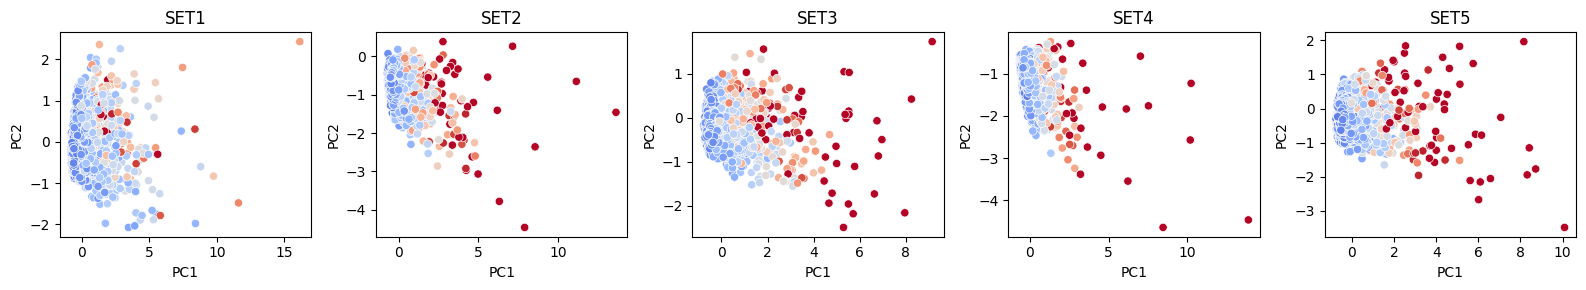

In [216]:
norm = TwoSlopeNorm(vmin=0, vcenter=0.6, vmax=1)


plt.figure(figsize = (16,3))

for i in range(1,6):
    test = pd.read_csv(Path(path, f'latent_scores_SET{i}.csv'))

    test_arr = test[latent_cols].to_numpy()

    plt.subplot(1,5,i)

    #test_arr = ss.transform(test_arr)
    plt.title(f'SET{i}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    test_2comp = pca.transform(test_arr)
    sns.scatterplot(x = test_2comp[:,0],
                    y = test_2comp[:,1], 
                    hue = test['error_acc'], 
                    legend = False, 
                    palette = 'coolwarm', 
                    alpha = 1,
                    hue_norm = norm)


plt.tight_layout()
plt.show()

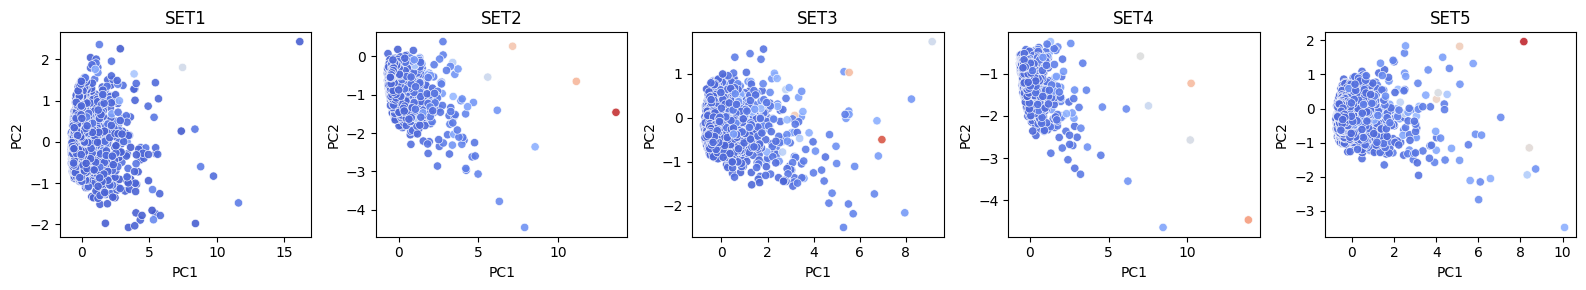

In [ ]:

norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)



plt.figure(figsize = (16,3))


for i in range(1,6):
    test = pd.read_csv(Path(path, f'latent_scores_SET{i}.csv'))

    test_arr = test[latent_cols].to_numpy()

    plt.subplot(1,5,i)

    #test_arr = ss.transform(test_arr)
    plt.title(f'SET{i}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    test_2comp = pca.transform(test_arr)
    sns.scatterplot(x = test_2comp[:,0],
                    y = test_2comp[:,1], 
                    hue = test['error_strain'], 
                    legend = False, 
                    palette = 'coolwarm', 
                    alpha = 0.9,
                    hue_norm = norm)


plt.tight_layout()
plt.show()

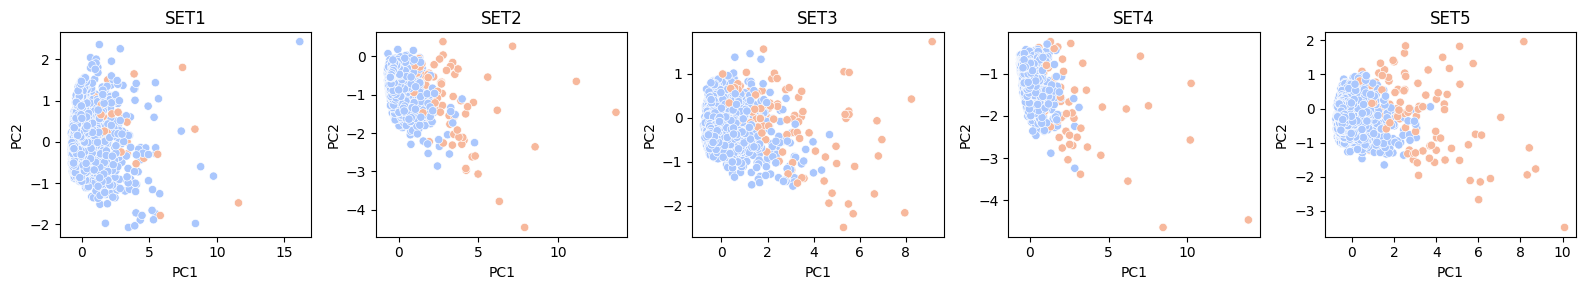

In [204]:
plt.figure(figsize = (16,3))

for i in range(1,6):
    test = pd.read_csv(Path(path, f'latent_scores_SET{i}.csv'))

    test_arr = test[latent_cols].to_numpy()

    plt.subplot(1,5,i)

    #test_arr = ss.transform(test_arr)
    plt.title(f'SET{i}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    test_2comp = pca.transform(test_arr)
    sns.scatterplot(x = test_2comp[:,0],y = test_2comp[:,1], hue = test['above_threshold'], legend = False, palette = 'coolwarm', alpha = 1)


plt.tight_layout()
plt.show()

In [10]:
#To be honest, the creation of this could also be its own script lol 

class SensorDataset(Dataset):

    def __init__(
        self,
        acc_data,
        strain_data
    ):

        self.acc = torch.tensor(
            acc_data,
            dtype=torch.float32
        )

        self.strain = torch.tensor(
            strain_data,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.acc)

    def __getitem__(self, idx):

        return {
            "acc": self.acc[idx],
            "strain": self.strain[idx]
        }


def get_dataloaders(acc, strain, event_masks, set_idx = 0):

    acc_set = acc[event_masks[set_idx]]
    strain_set = strain[event_masks[set_idx]]

    dataset = SensorDataset(
        acc_set,
        strain_set
    )


    N = len(dataset)

    train_size = int(0.7 * N)
    test_size = int(0.2 * N)
    val_size = N - train_size - test_size


    generator = torch.Generator().manual_seed(
        42
    )

    # Split first
    train_dataset, test_dataset, val_dataset = random_split(
        dataset,
        [train_size, test_size, val_size],
        generator=generator
    )

    # Get indices from splits
    train_idx = train_dataset.indices
    test_idx = test_dataset.indices
    val_idx = val_dataset.indices

    # Extract raw arrays
    acc_train = acc_set[train_idx]
    acc_test = acc_set[test_idx]
    acc_val = acc_set[val_idx]

    strain_train = strain_set[train_idx]
    strain_test = strain_set[test_idx]
    strain_val = strain_set[val_idx]


    acc_scaler = StandardScaler()

    # flatten feature dimension temporarily
    acc_shape = acc_train.shape

    acc_train_scaled = acc_scaler.fit_transform(
        acc_train.reshape(-1, acc_train.shape[-1])
    ).reshape(acc_shape)

    acc_test_scaled = acc_scaler.transform(
        acc_test.reshape(-1, acc_test.shape[-1])
    ).reshape(acc_test.shape)

    acc_val_scaled = acc_scaler.transform(
        acc_val.reshape(-1, acc_val.shape[-1])
    ).reshape(acc_val.shape)


    strain_scaler = StandardScaler()

    strain_shape = strain_train.shape

    strain_train_scaled = strain_scaler.fit_transform(
        strain_train.reshape(-1, strain_train.shape[-1])
    ).reshape(strain_shape)

    strain_test_scaled = strain_scaler.transform(
        strain_test.reshape(-1, strain_test.shape[-1])
    ).reshape(strain_test.shape)

    strain_val_scaled = strain_scaler.transform(
        strain_val.reshape(-1, strain_val.shape[-1])
    ).reshape(strain_val.shape)

    # Rebuild datasets
    train_dataset = SensorDataset(
        acc_train_scaled,
        strain_train_scaled
    )

    test_dataset = SensorDataset(
        acc_test_scaled,
        strain_test_scaled
    )

    val_dataset = SensorDataset(
        acc_val_scaled,
        strain_val_scaled
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=64,
        shuffle=False
    )

    return train_loader, test_loader, val_loader

In [ ]:
event_masks = [
    [event_id.startswith(f"AQUINAS_SET{x}")
     for event_id in event_ids]
    for x in range(1,6)
]



In [11]:
train, test, val = get_dataloaders(acc, strain, event_masks)


In [12]:
train